In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import color

from tqdm.auto import tqdm

from PIL import Image

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import models
import inference
import utils
import visu
import data

In [14]:
category = 15

train_dataset, test_dataset = data.single_cat_OxfordIIITPet(category)

  0%|          | 0/3680 [00:00<?, ?it/s]

  0%|          | 0/3669 [00:00<?, ?it/s]

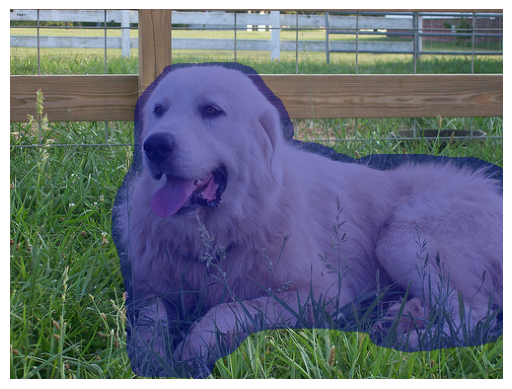

In [15]:
i = 0

image, (mask, cat) = train_dataset[i]
mask = utils.preprocess(mask)

visu.plot_mask(image, mask)

In [ ]:
n_segments=100
compactness=20


def agg_func(x):
    return np.mean(x, axis=0)

def agg_func(x):
    x = x / 255.0

    x_lab = color.rgb2lab(x.reshape(-1, 1, 3)).reshape(-1, 3)

    mean = np.mean(x_lab, axis=0)
    std = np.std(x_lab, axis=0)
    
    return np.concatenate([mean, std])

def agg_func(x, bins=8):
    
    print(x)

    # Convert to Lab
    x_lab = color.rgb2lab(x.reshape(-1, 1, 3)).reshape(-1, 3)

    # Mean & std
    mean = np.mean(x_lab, axis=0)
    std = np.std(x_lab, axis=0)

    # Histograms (per channel)
    hist_features = []
    for i in range(3):
        hist, _ = np.histogram(
            x_lab[:, i],
            bins=bins,
            density=True
        )
        hist_features.append(hist)

    hist_features = np.concatenate(hist_features)

    # Final feature vector
    return np.concatenate([mean, std, hist_features])

features, labels = utils.extract_super_features(train_dataset, n_segments, compactness, agg_func)
features, labels = utils.balance_data(features, labels)

In [17]:
logisticMask = models.SuperLogisticMask(agg_func=agg_func)
rdfMask = models.SuperSegment(RandomForestClassifier(10, max_depth=2), agg_func=agg_func)
densityMask = models.SuperDensityMask(agg_func=agg_func)

logisticMask.fit(features, labels)
rdfMask.fit(features, labels)
densityMask.fit(features, labels)

In [18]:
max_iter = 100
model = densityMask

ious = inference.sequential_segmentation(test_dataset, model, max_iter, trw=True)
print("Mean IoU:", ious.mean())

  0%|          | 0/100 [00:00<?, ?it/s]

/home/hugo/Documents/CS/GRM/models.py:112: RuntimeWarning: invalid value encountered in divide
  probs = probs / np.sum(probs, axis=0)
/home/hugo/Documents/CS/GRM/models.py:112: RuntimeWarning: invalid value encountered in divide
  probs = probs / np.sum(probs, axis=0)
/home/hugo/Documents/CS/GRM/models.py:112: RuntimeWarning: invalid value encountered in divide
  probs = probs / np.sum(probs, axis=0)
/home/hugo/Documents/CS/GRM/models.py:112: RuntimeWarning: invalid value encountered in divide
  probs = probs / np.sum(probs, axis=0)
/home/hugo/Documents/CS/GRM/models.py:112: RuntimeWarning: invalid value encountered in divide
  probs = probs / np.sum(probs, axis=0)


KeyboardInterrupt: 

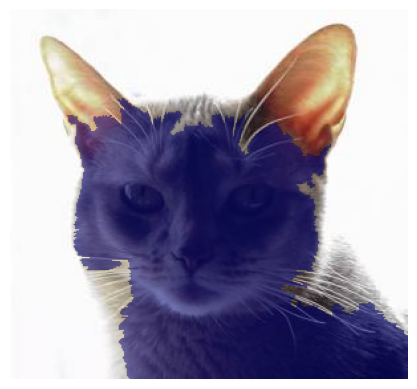

0.6617893701925858


In [7]:
i = 4
max_iter = 100

image, (mask, cat) = test_dataset[i]
mask = utils.preprocess(mask)
image = np.array(image)

predictions = model(image, max_iter, trw=True)
    
visu.plot_mask(image, predictions)
print(utils.IoU(mask, predictions))